# My PayPal

Credit card companies must recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.

For this project, I will use a somewhat de-identified dataset of credit card transactions in Europe. The dataset contains transactions made by credit cards in September 2013 by European cardholders. This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced. The positive class (frauds) accounts for 0.172% of all transactions.

It contains only numerical input variables, which are the result of a PCA transformation. Unfortunately, we cannot provide the original features and more background information about the data due to confidentiality issues. Features V1, V2, … V28 are the principal components obtained with PCA. The only features that have not been transformed with PCA are 'Time' and 'Amount.' Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount; for example-dependant cost-sensitive learning. Feature 'Class' is the response variable, and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, it is recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

I have been hired by FriendPay, a competitor of PayPal, to help them improve their credit card fraud identification system. They are having difficulty identifying which transactions are or are not fraudulent, and this is creating significant business problems that are costing them a lot in missed transaction fees.

My Mission is to build a fraud detection model using the dataset that has been provided and in doing so, increase revenue from transaction fees.


## Table of contents:
* [Imports](#imports)
* [Data Loading and EDA](#data-loading)
* [Feature selection](#feature-selection)
* [Train/Test split](#split)
* [Feature scaling](#feature-scaling)
* [Balancing data](#balance)
* [Baseline model](#baseline)
* [Main model](#main)
* [Hyperparameter optimization](#hyperparameter-optimization)

## Imports <a class="anchor" id="imports"></a>

In [64]:
import mlflow
import optuna
import mlflow.sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from mlflow.models import infer_signature
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [33]:
tracking_uri = "http://127.0.0.1:5000/"
mlflow.set_tracking_uri(tracking_uri)
experiment = mlflow.set_experiment("my_paypal")

In [8]:
def check_missing_values(df):
    missing_stats = pd.DataFrame({
        "total_missing": df.isnull().sum(),
        "percent_missing": (df.isnull().sum() / len(df) * 100).round(2)
    }).sort_values("percent_missing", ascending=False)
    
    missing_stats["impact"] = missing_stats["percent_missing"].apply(
        lambda x: "High" if x > 15 else ("Medium" if x > 5 else "Low")
    )
    return missing_stats

def check_duplicates(df, subset_columns=None):
    duplicate_report = {
        "exact_duplicates": df.duplicated().sum(),
        "partial_duplicates": df.duplicated(subset=subset_columns).sum() if subset_columns else 0
    }
    return duplicate_report
    
def visualize_class_balance(class_col: list[int], abs_nums: bool = False) -> None:
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(aspect="equal"))

    labels = ["0", "1"]
    title = "Class comparisons of the target variable - "
    
    total = sum(class_col)
    percentages = [f"{labels[i]} ({class_col[i] / total * 100:.3f}%)" for i in range(len(labels))]
    
    wedges, texts = ax.pie(class_col, wedgeprops=dict(width=0.5), startangle=-40)
    
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    kw = dict(arrowprops=dict(arrowstyle="-"),
              bbox=bbox_props, zorder=0, va="center")
    
    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1) / 2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        kw["arrowprops"].update({"connectionstyle": connectionstyle})

        if abs_nums is True:
            ax.annotate(class_col[i], xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                    horizontalalignment=horizontalalignment, **kw)
        else:    
            ax.annotate(percentages[i], xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                        horizontalalignment=horizontalalignment, **kw)

    if abs_nums is True:
        title += "absolute"
    else:
        title += "relative"
    
    ax.set_title(title)
    
    plt.show()

## Data loading and EDA <a class="anchor" id="data-loading"></a>

In [20]:
df = pd.read_csv("my_paypal_creditcard.csv")

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [22]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Check for missing values

In [23]:
check_missing_values(df)

,total_missing,percent_missing,impact
Time,0,0.0,Low
V16,0,0.0,Low
Amount,0,0.0,Low
V28,0,0.0,Low
V27,0,0.0,Low
V26,0,0.0,Low
V25,0,0.0,Low
V24,0,0.0,Low
V23,0,0.0,Low
V22,0,0.0,Low


Check for duplitcats

In [24]:
check_duplicates(df)

{'exact_duplicates': np.int64(1081), 'partial_duplicates': 0}

In [25]:
df = df.drop_duplicates()
check_duplicates(df)

{'exact_duplicates': np.int64(0), 'partial_duplicates': 0}

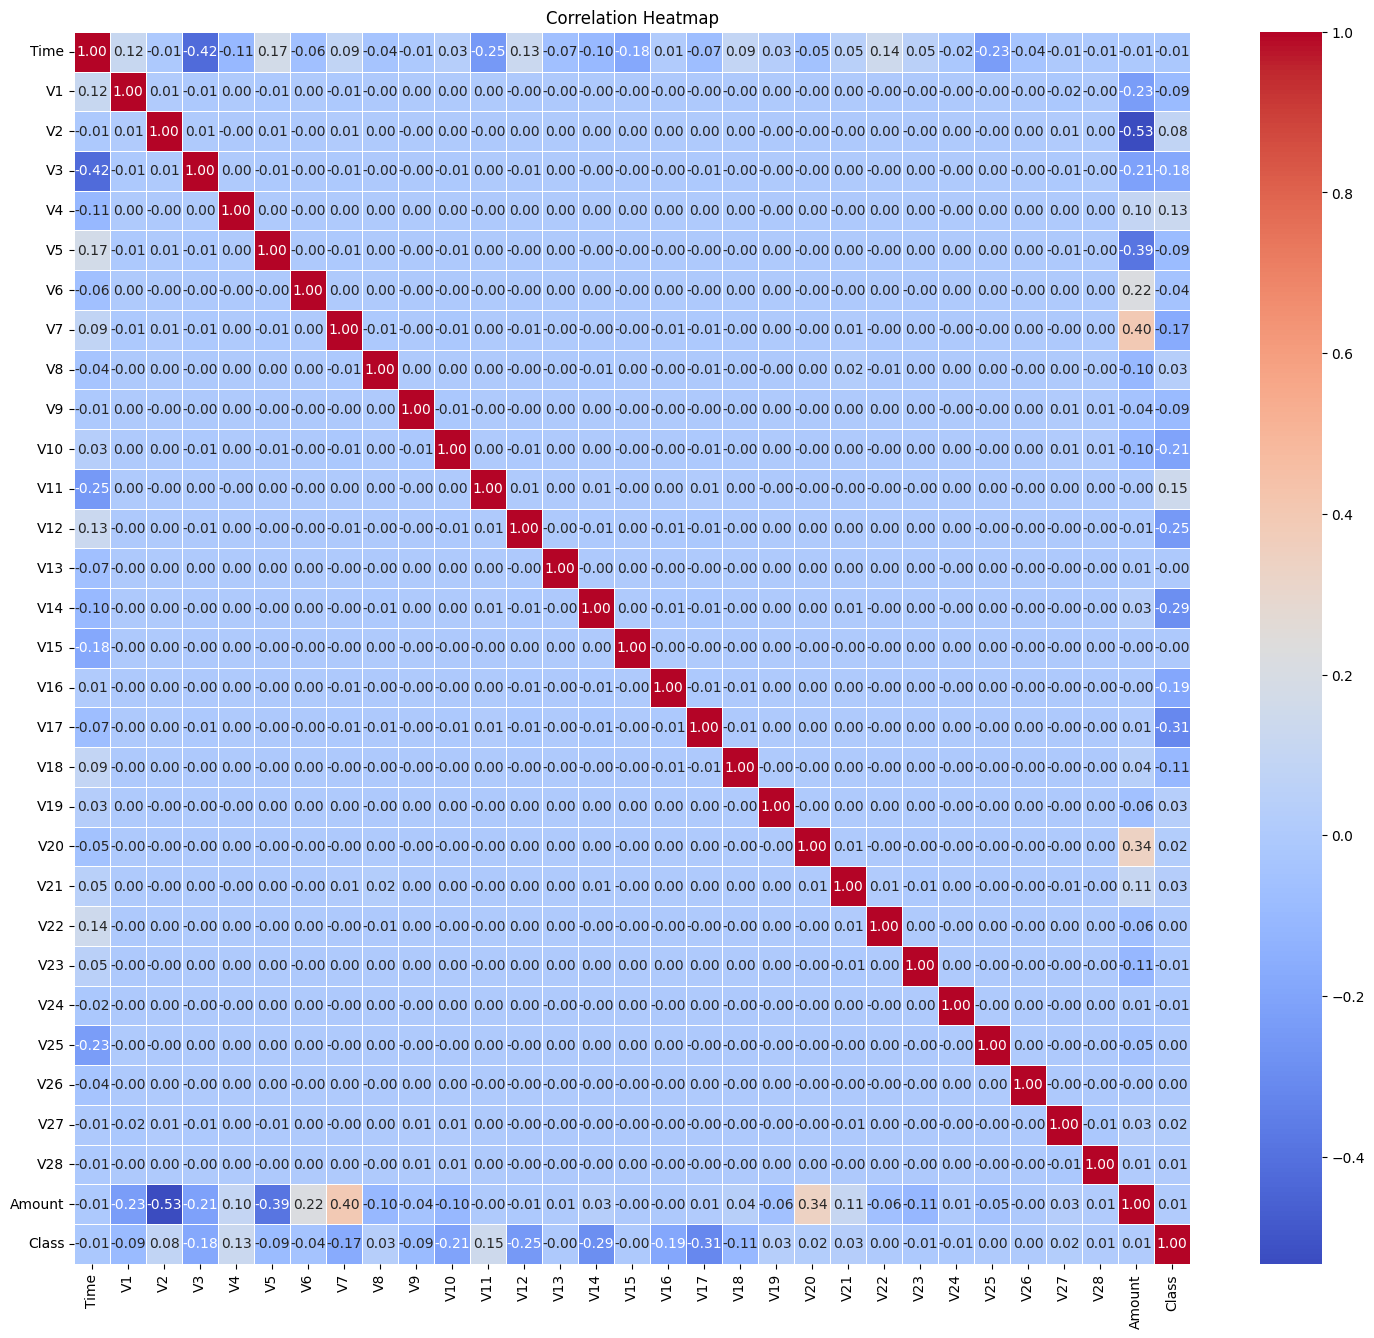

In [26]:
matrix = df.corr()

plt.figure(figsize=(18,16))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.savefig("corr_matrix.jpg")
plt.show()

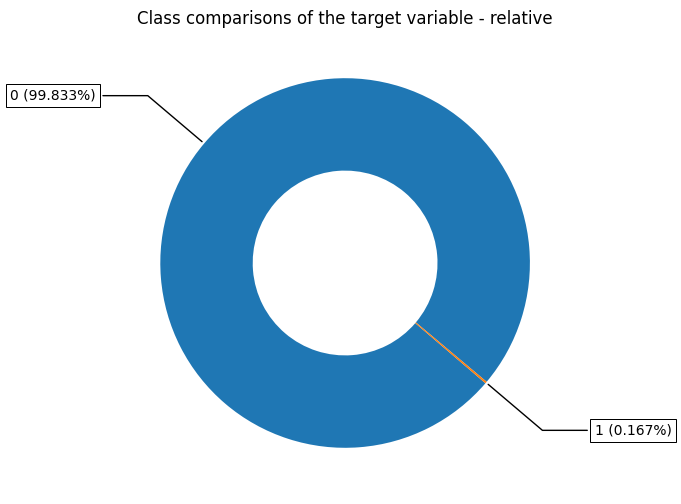

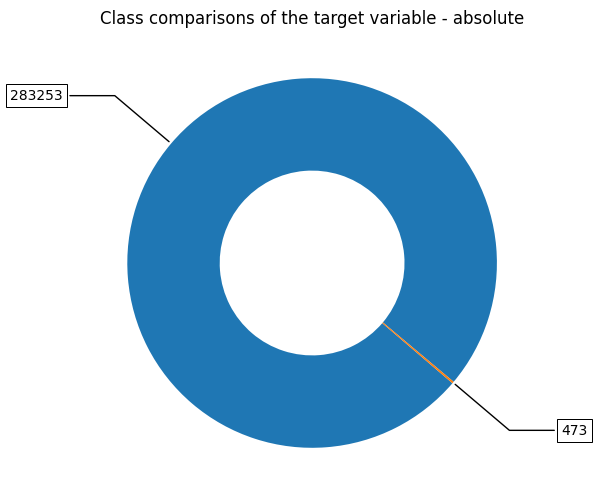

In [27]:
target_list = df["Class"].value_counts().to_list()
visualize_class_balance(target_list)
visualize_class_balance(target_list, abs_nums=True)

It is clear that the dataset is highly imbalanced. In some of my previous projects I have used some oversampling approaches such as SMOTE. In this case I will implement it as well influenced by this paper: https://drive.google.com/file/d/1WOHXFXO5xF-zQxotg4Hr0it_3SPDFrvx/view <br> Moreover, based on it, I will implement LogisticRegression as a baseline model and utilize Random Forest Classifier for main model, having in mind, the paper suggests it is the best among the tested algorithms. Below I have listed a comparison of different algorithms that I have already tested on this data. The main goal is to achieve high Area Under the Precision-Recall Curve. While trying to minimize the lost transaction fees, I will focus on lowering to a minimum the false-positives because such transactions would have a huge negative impact on any bank.

Check data statistics

In [28]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


Having in mind the above statistics, it seems that scaling must be performed.

## Feature selection based on the correlation matrix above <a class="anchor" id="feature-selection"></a>

In [29]:
df = df.drop(columns=["V13", "V15", "V22", "V23", "V25", "V26"])

## Train/Test split <a class="anchor" id="split"></a>

In [54]:
X = df.drop(columns=["Class"])
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.3)

## Feature scaling <a class="anchor" id="feature-scaling"></a>

In [40]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Balancing data with oversampling - SMOTE <a class="anchor" id="balance"></a>

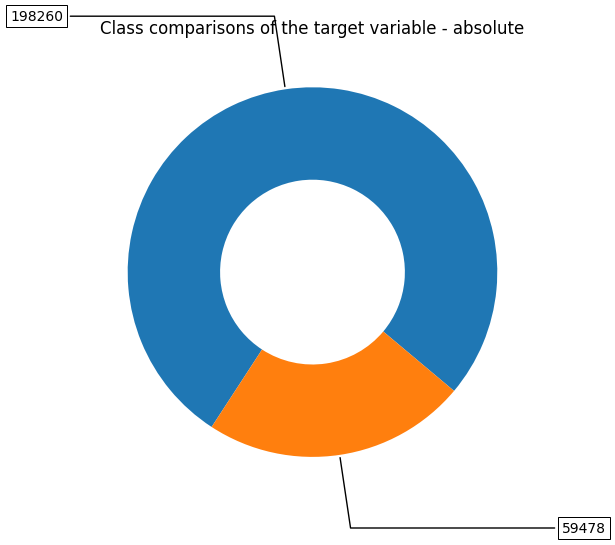

In [59]:
smote = SMOTE( # all from the search optimization below
    sampling_strategy=0.3, 
    k_neighbors=7
)
X_train, y_train = smote.fit_resample(X_train, y_train)
target_list = y_train.value_counts().to_list()
visualize_class_balance(target_list, abs_nums=True)

## Baseline classification model <a class="anchor" id="baseline"></a>

In [55]:
baseline_lr = LogisticRegression()
baseline_lr.fit(X_train, y_train)
y_pred = baseline_lr.predict(X_test)

/Users/nikolaykirilov/Documents/University/qwasar/my_paypal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [56]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84993
           1       0.61      0.66      0.63       125

    accuracy                           1.00     85118
   macro avg       0.81      0.83      0.82     85118
weighted avg       1.00      1.00      1.00     85118



In [57]:
roc_auc_score(y_test, y_pred)

0.8276940924546727

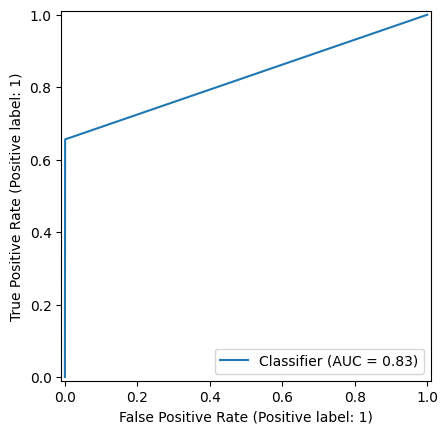

In [58]:
RocCurveDisplay.from_predictions(y_test, y_pred)
plt.show()

## Main model <a class="anchor" id="main"></a>

In [60]:
%%time
with mlflow.start_run():
    model = RandomForestClassifier( # all from the search optimization below
        n_estimators=335,
        max_depth=6,
        min_samples_leaf=40,
        max_features="log2",
        max_samples=0.639,
        class_weight="balanced_subsample",
        random_state=1
    )
    model.fit(X_train, y_train)
    y_preds = model.predict(X_test) 
    for param, value in model.get_params().items():
        mlflow.log_param(param, value)

    signature = infer_signature(X_train, y_train)
    mlflow.sklearn.log_model(model, "model", signature=signature)
    
    roc_auc_metric = roc_auc_score(y_test, y_preds)
    mlflow.log_metrics(
        {
            "roc_auc_metric": roc_auc_metric,
            "test_size": len(y_test),
            "train_size": len(y_train),
            "test_support_1": len(y_test[y_test == 1]),
            "test_support_0": len(y_test[y_test == 0]),
            "train_support_1": len(y_train[y_train == 1]),
            "train_support_0": len(y_train[y_train == 0])
        }
    )

/Users/nikolaykirilov/Documents/University/qwasar/my_paypal/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/01/02 13:43:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run bold-roo-377 at: http://127.0.0.1:5000/#/experiments/1/runs/f584dcd87222438d96cb67629c225b35
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
CPU times: user 1min 39s, sys: 1.7 s, total: 1min 41s
Wall time: 1min 43s


In [61]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84993
           1       0.25      0.81      0.38       125

    accuracy                           1.00     85118
   macro avg       0.63      0.90      0.69     85118
weighted avg       1.00      1.00      1.00     85118



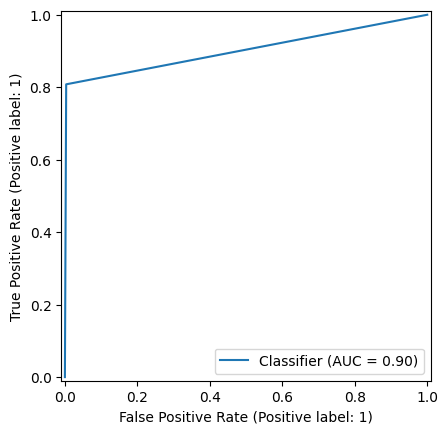

In [62]:
RocCurveDisplay.from_predictions(y_test, y_preds)
plt.show()

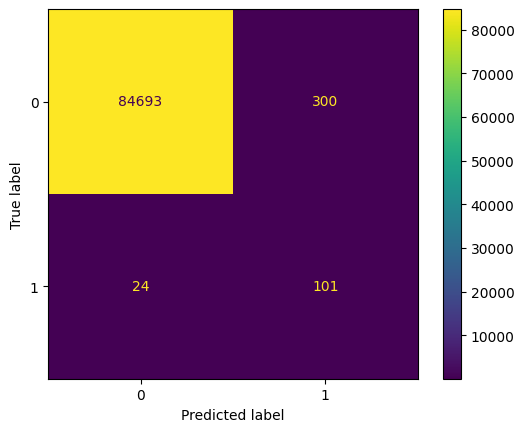

In [63]:
ConfusionMatrixDisplay.from_predictions(y_test, y_preds)
plt.show()

The first step after the pure data has been given to the model and tested on other algorithms, was to balance the data using SMOTE. After this operation the main model - RandomForestClassifier moved from <b>0.88 AUC </b> to <b>0.90 AUC</b>. Second step was to perform feature selection. Before it, the time to train the model was about <b> 3:25 min </b>, after removing the features with correlation <b> 0.00 </b> the time to train the model was lowered to <b> 2:39 min </b> while the AUC and F1 score stayed as high as with the removed columns. <br><br> After the hyperparameter search below, and adding `n_estimators=152` and `max_depth=7` the AUC increased to <b>0.91</b>. Then, I performed another search in which I optimized for `recall`, after it only the `n_estimators` increased to `165` and the AUC stayed <b>0.91</b>. After that, I performed on more search optimizing for `AUC` with more hyperparameters `n_estimators=335, max_depth=6, min_samples_leaf=40, max_features="log2", max_samples=0.639, class_weight="balanced_subsample", random_state=1` and different paramters for SMOTE - `sampling_strategy=0.3, k_neighbors=7`, however the AUC score did not improve and stayed <b>0.91</b> yet the time to train the model lowered to <b>1:41 min</b>.

<b><center> Here is a comparison of several algorithms on the current data WITHOUT any actions taken to optimize the given metrics: </center></b>


| Model        | F1 Score | AUC  |
|--------------|----------|------|
| LogisticRegression     |  0.82        | 0.79     |
| RandomForestClassifier     |  0.91        | 0.88     |
| SGDOneClassSVM      | 0.00          | 0.50     |
| EllipticEnvelope      |  0.00        |   0.26   |
| IsolationForest      |  0.00        |   0.11   |
| LocalOutlierFactor      |  0.00        |   0.42   |


## Hyperparameter search/optimization <a class="anchor" id="hyperparameter-optimization"></a>

In [42]:
%%time
def objective(trial):
    rf_params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 2, 50),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 0.8),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"]),
        "random_state": 1,
    }
    
    k_neighbors = trial.suggest_int("k_neighbors", 1, 7)
    sampling_strategy = trial.suggest_float("sampling_strategy", 0.1, 0.5)

    model_pipeline = Pipeline([
        ("smote", SMOTE(k_neighbors=k_neighbors, sampling_strategy=sampling_strategy, random_state=1)),
        ("classifier", RandomForestClassifier(**rf_params))
    ])

    score = cross_val_score(model_pipeline, X, y, cv=3, scoring="roc_auc")
    
    return score.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print(f"Best Accuracy: {study.best_value}")
print(f"Best Hyperparameters: {study.best_params}")

[I 2025-12-18 16:58:17,959] A new study created in memory with name: no-name-91930e75-059d-4ba1-b7ee-efc982424a71
[I 2025-12-18 17:02:54,577] Trial 0 finished with value: 0.9782262636356426 and parameters: {'n_estimators': 335, 'max_depth': 6, 'min_samples_leaf': 40, 'max_features': 'log2', 'max_samples': 0.6392443880988331, 'class_weight': 'balanced_subsample', 'k_neighbors': 7, 'sampling_strategy': 0.30540160433336194}. Best is trial 0 with value: 0.9782262636356426.
[I 2025-12-18 17:08:39,025] Trial 1 finished with value: 0.9712362953079978 and parameters: {'n_estimators': 223, 'max_depth': 24, 'min_samples_leaf': 22, 'max_features': 'log2', 'max_samples': 0.7498658216616497, 'class_weight': 'balanced', 'k_neighbors': 7, 'sampling_strategy': 0.1654469204113559}. Best is trial 0 with value: 0.9782262636356426.
[I 2025-12-18 17:11:21,545] Trial 2 finished with value: 0.9661850195890418 and parameters: {'n_estimators': 127, 'max_depth': 24, 'min_samples_leaf': 13, 'max_features': 'sqrt

Best Accuracy: 0.9782262636356426
Best Hyperparameters: {'n_estimators': 335, 'max_depth': 6, 'min_samples_leaf': 40, 'max_features': 'log2', 'max_samples': 0.6392443880988331, 'class_weight': 'balanced_subsample', 'k_neighbors': 7, 'sampling_strategy': 0.30540160433336194}
CPU times: user 59min 34s, sys: 1min 4s, total: 1h 38s
Wall time: 59min 39s
